# 08 — Channel Selection

Owner: Yuki

Two questions from Ishanvir:

> **(a)** Does a 4-channel occipital subset (e.g., O1/Oz/O2 + POz) match 8-channel CCA performance? If yes, that's a real practical result.  
> **(b)** Per-subject channel ranking: does subject 2's optimal channel subset differ from subject 1's? If yes, that connects directly to the universality story.

**Approach:**
1. Rank channels by mean SSVEP SNR (SNR = power at stim freq / mean flanking noise).
2. Sweep top-1 through top-8 channel subsets with LOBO-CV CCA — plot accuracy vs n_channels.
3. Repeat per subject to answer question (b).
4. Test the *specific* O1/Oz/O2/POz subset Ishanvir proposed.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from ssvep import io, evaluation
from ssvep.io import CH_NAMES, STIM_FREQS
from ssvep.classifiers import CCAClassifier
from ssvep.channel_selection import rank_channels_by_snr, channel_snr_matrix, sweep_channel_subsets

DATA_DIR = '../data/raw'
FIG_DIR  = '../results/figures'
FS = 256.0
WINDOW_S = 3.0
CH_NAMES = list(CH_NAMES)  # ['PO7','PO3','POz','PO4','PO8','O1','Oz','O2']
print('Channels:', CH_NAMES)

Channels: ['PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2']


## 1. Load data

In [2]:
ds_all = io.load_all(DATA_DIR, window_s=WINDOW_S)
X_all, y_all, blocks_all = ds_all['X'], ds_all['y'], ds_all['blocks']
print(f'All data: X={X_all.shape}, y={y_all.shape}, blocks={np.unique(blocks_all)}')

# blocks 0,1 = subject_1 | blocks 2,3 = subject_2
mask_s1 = blocks_all <= 1
mask_s2 = blocks_all >= 2
X_s1, y_s1, blocks_s1 = X_all[mask_s1], y_all[mask_s1], blocks_all[mask_s1]
X_s2, y_s2, blocks_s2 = X_all[mask_s2], y_all[mask_s2], blocks_all[mask_s2]
print(f'Subject 1: {X_s1.shape[0]} trials | Subject 2: {X_s2.shape[0]} trials')

All data: X=(80, 8, 768), y=(80,), blocks=[0 1 2 3]
Subject 1: 40 trials | Subject 2: 40 trials


## 2. Channel SNR ranking

In [3]:
snr_all, rank_all = rank_channels_by_snr(X_all, y_all, FS, STIM_FREQS)
snr_s1,  rank_s1  = rank_channels_by_snr(X_s1,  y_s1,  FS, STIM_FREQS)
snr_s2,  rank_s2  = rank_channels_by_snr(X_s2,  y_s2,  FS, STIM_FREQS)

print('=== Overall ranking (best -> worst) ===')
for i, ch in enumerate(rank_all):
    print(f'  #{i+1}: {CH_NAMES[ch]:5s}  SNR={snr_all[ch]:.3f}')

print('\n=== Subject 1 ranking ===')
for i, ch in enumerate(rank_s1):
    print(f'  #{i+1}: {CH_NAMES[ch]:5s}  SNR={snr_s1[ch]:.3f}')

print('\n=== Subject 2 ranking ===')
for i, ch in enumerate(rank_s2):
    print(f'  #{i+1}: {CH_NAMES[ch]:5s}  SNR={snr_s2[ch]:.3f}')

=== Overall ranking (best -> worst) ===
  #1: O2     SNR=1.361
  #2: O1     SNR=1.319
  #3: PO8    SNR=1.318
  #4: Oz     SNR=1.310
  #5: PO3    SNR=1.298
  #6: PO4    SNR=1.267
  #7: POz    SNR=1.237
  #8: PO7    SNR=1.193

=== Subject 1 ranking ===
  #1: O2     SNR=1.547
  #2: O1     SNR=1.526
  #3: Oz     SNR=1.505
  #4: PO8    SNR=1.414
  #5: PO3    SNR=1.406
  #6: PO4    SNR=1.298
  #7: PO7    SNR=1.286
  #8: POz    SNR=1.263

=== Subject 2 ranking ===
  #1: PO4    SNR=1.235
  #2: PO8    SNR=1.222
  #3: POz    SNR=1.211
  #4: PO3    SNR=1.190
  #5: O2     SNR=1.176
  #6: Oz     SNR=1.115
  #7: O1     SNR=1.111
  #8: PO7    SNR=1.101


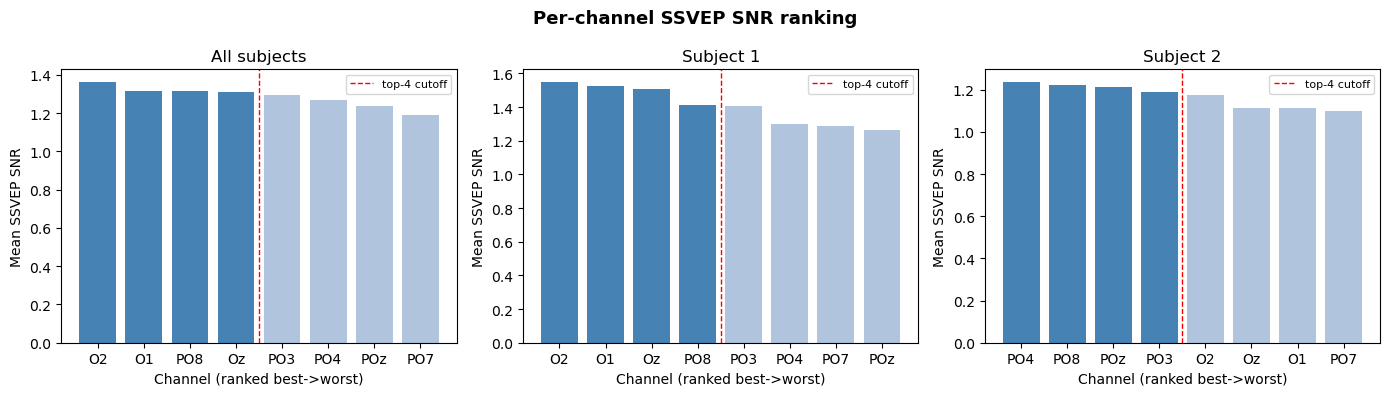

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, snr, ranking, title in zip(
    axes,
    [snr_all, snr_s1, snr_s2],
    [rank_all, rank_s1, rank_s2],
    ['All subjects', 'Subject 1', 'Subject 2'],
):
    sorted_snr   = snr[ranking]
    sorted_names = [CH_NAMES[i] for i in ranking]
    colors = ['steelblue' if i < 4 else 'lightsteelblue' for i in range(len(ranking))]
    ax.bar(sorted_names, sorted_snr, color=colors)
    ax.set_title(title)
    ax.set_xlabel('Channel (ranked best->worst)')
    ax.set_ylabel('Mean SSVEP SNR')
    ax.axvline(3.5, color='red', linestyle='--', linewidth=1, label='top-4 cutoff')
    ax.legend(fontsize=8)

fig.suptitle('Per-channel SSVEP SNR ranking', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/channel_snr_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. SNR heatmap: frequency x channel

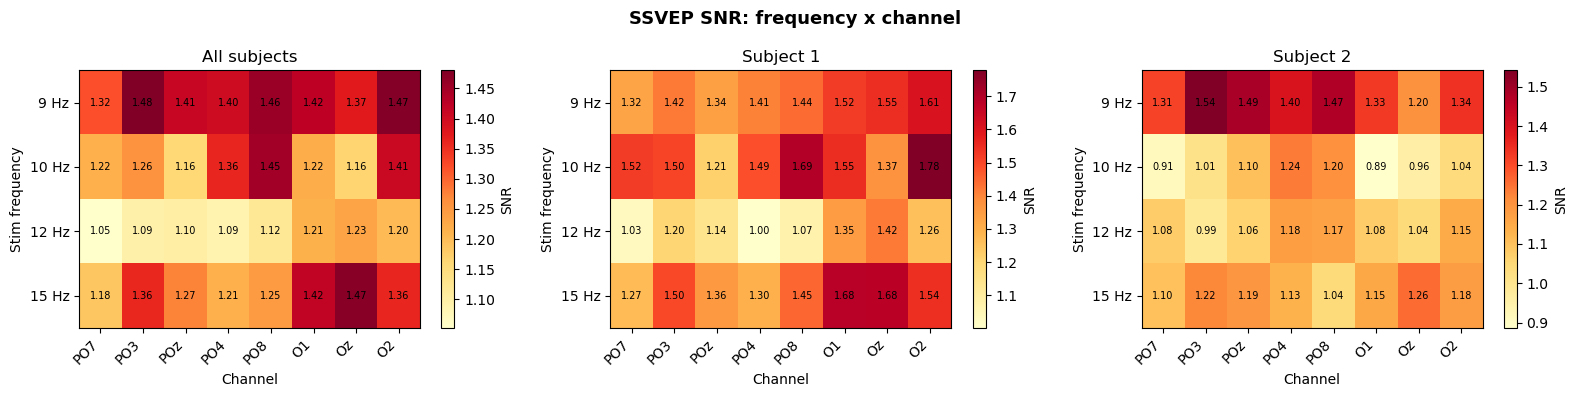

In [5]:
snr_mat_all = channel_snr_matrix(X_all, y_all, FS, STIM_FREQS)
snr_mat_s1  = channel_snr_matrix(X_s1,  y_s1,  FS, STIM_FREQS)
snr_mat_s2  = channel_snr_matrix(X_s2,  y_s2,  FS, STIM_FREQS)

freq_labels = [f'{f:.0f} Hz' for f in STIM_FREQS]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, mat, title in zip(
    axes,
    [snr_mat_all, snr_mat_s1, snr_mat_s2],
    ['All subjects', 'Subject 1', 'Subject 2'],
):
    im = ax.imshow(mat, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(len(CH_NAMES)))
    ax.set_xticklabels(CH_NAMES, rotation=45, ha='right')
    ax.set_yticks(range(len(STIM_FREQS)))
    ax.set_yticklabels(freq_labels)
    ax.set_title(title)
    ax.set_xlabel('Channel')
    ax.set_ylabel('Stim frequency')
    plt.colorbar(im, ax=ax, label='SNR')
    for r in range(mat.shape[0]):
        for c in range(mat.shape[1]):
            ax.text(c, r, f'{mat[r,c]:.2f}', ha='center', va='center', fontsize=7)

fig.suptitle('SSVEP SNR: frequency x channel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/channel_snr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. CCA accuracy sweep: top-N channels (LOBO-CV)

For each N from 1 to 8, use the top-N channels by SNR and run Leave-One-Block-Out CV.

In [6]:
print('Running sweep (all data)...')
sweep_all = sweep_channel_subsets(X_all, y_all, blocks_all, FS, STIM_FREQS, rank_all)
print('Running sweep (subject 1)...')
sweep_s1  = sweep_channel_subsets(X_s1,  y_s1,  blocks_s1,  FS, STIM_FREQS, rank_s1)
print('Running sweep (subject 2)...')
sweep_s2  = sweep_channel_subsets(X_s2,  y_s2,  blocks_s2,  FS, STIM_FREQS, rank_s2)
print('Done.')

Running sweep (all data)...
Running sweep (subject 1)...
Running sweep (subject 2)...
Done.


In [7]:
print(f'{"N":>3}  {"Top channels":30}  {"All":>6}  {"S1":>6}  {"S2":>6}')
print('-' * 60)
for n in range(1, 9):
    ch_str = '+'.join(CH_NAMES[i] for i in rank_all[:n])
    print(f'{n:>3}  {ch_str:30}  {sweep_all[n]["mean"]:.3f}  {sweep_s1[n]["mean"]:.3f}  {sweep_s2[n]["mean"]:.3f}')

  N  Top channels                       All      S1      S2
------------------------------------------------------------
  1  O2                              0.575  0.775  0.500
  2  O2+O1                           0.688  0.950  0.525
  3  O2+O1+PO8                       0.825  0.975  0.650
  4  O2+O1+PO8+Oz                    0.812  1.000  0.700
  5  O2+O1+PO8+Oz+PO3                0.750  1.000  0.700
  6  O2+O1+PO8+Oz+PO3+PO4            0.775  1.000  0.725
  7  O2+O1+PO8+Oz+PO3+PO4+POz        0.825  1.000  0.675
  8  O2+O1+PO8+Oz+PO3+PO4+POz+PO7    0.838  1.000  0.675


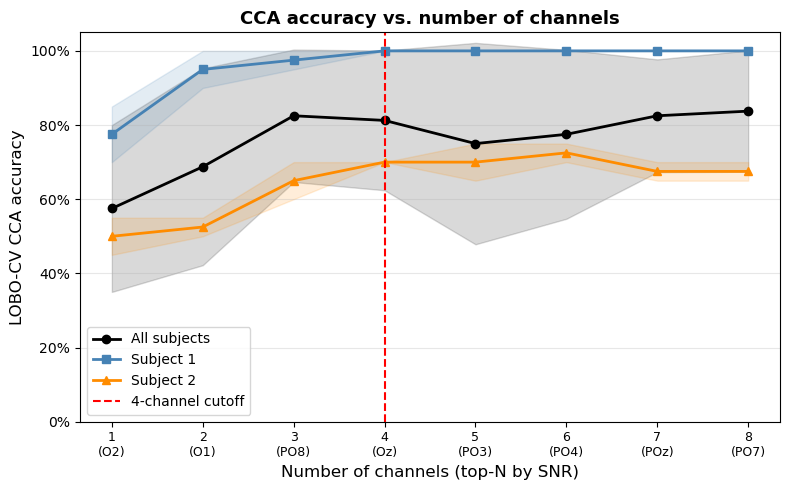

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ns = list(range(1, 9))

for sweep, label, color, marker in [
    (sweep_all, 'All subjects', 'black',     'o'),
    (sweep_s1,  'Subject 1',   'steelblue',  's'),
    (sweep_s2,  'Subject 2',   'darkorange', '^'),
]:
    means = [sweep[n]['mean'] for n in ns]
    stds  = [sweep[n]['std']  for n in ns]
    ax.plot(ns, means, marker=marker, color=color, label=label, linewidth=2)
    ax.fill_between(ns,
                    [m - s for m, s in zip(means, stds)],
                    [m + s for m, s in zip(means, stds)],
                    alpha=0.15, color=color)

ax.axvline(4, color='red', linestyle='--', linewidth=1.5, label='4-channel cutoff')
ax.set_xlabel('Number of channels (top-N by SNR)', fontsize=12)
ax.set_ylabel('LOBO-CV CCA accuracy', fontsize=12)
ax.set_title('CCA accuracy vs. number of channels', fontsize=13, fontweight='bold')
ax.set_xticks(ns)
ax.set_xticklabels([f'{n}\n({CH_NAMES[rank_all[n-1]]})' for n in ns], fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/channel_sweep_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Question (a): does 4-channel match 8-channel?

Also testing Ishanvir's specific proposal: **O1 / Oz / O2 / POz**.

In [9]:
# Proposed subset: O1=idx5, Oz=idx6, O2=idx7, POz=idx2
proposed_idx = np.array([5, 6, 7, 2])
print(f'Proposed subset: {[CH_NAMES[i] for i in proposed_idx]}')

def run_fixed_subset(X, y, blocks, ch_idx):
    X_sub = X[:, ch_idx, :]
    factory = lambda: CCAClassifier(stim_freqs=STIM_FREQS, fs=FS, n_harmonics=2)
    return evaluation.leave_one_block_out_cv(X_sub, y, blocks, factory)

r_prop_all = run_fixed_subset(X_all, y_all, blocks_all, proposed_idx)
r_prop_s1  = run_fixed_subset(X_s1,  y_s1,  blocks_s1,  proposed_idx)
r_prop_s2  = run_fixed_subset(X_s2,  y_s2,  blocks_s2,  proposed_idx)

print(f'\n{"":25} {"All":>8} {"S1":>8} {"S2":>8}')
print('-' * 55)
for label, ra, rs1, rs2 in [
    ('8-channel (all)',    sweep_all[8], sweep_s1[8], sweep_s2[8]),
    ('Top-4 by SNR',       sweep_all[4], sweep_s1[4], sweep_s2[4]),
    ('O1/Oz/O2/POz',       r_prop_all,   r_prop_s1,   r_prop_s2),
]:
    print(f'{label:25} {ra["mean"]:>8.3f} {rs1["mean"]:>8.3f} {rs2["mean"]:>8.3f}')

Proposed subset: ['O1', 'Oz', 'O2', 'POz']

                               All       S1       S2
-------------------------------------------------------
8-channel (all)              0.838    1.000    0.675
Top-4 by SNR                 0.812    1.000    0.700
O1/Oz/O2/POz                 0.787    0.975    0.600


## 6. Question (b): do S1 and S2 have different optimal subsets?

In [10]:
print('Subject 1 top-4:', [CH_NAMES[i] for i in rank_s1[:4]])
print('Subject 2 top-4:', [CH_NAMES[i] for i in rank_s2[:4]])

overlap = set(rank_s1[:4].tolist()) & set(rank_s2[:4].tolist())
print(f'Shared channels: {[CH_NAMES[i] for i in overlap]}')

# Apply S1's ranking to S2's data
r_s1rank_on_s2 = run_fixed_subset(X_s2, y_s2, blocks_s2, rank_s1[:4])
r_s2rank_on_s2 = run_fixed_subset(X_s2, y_s2, blocks_s2, rank_s2[:4])

print(f'\nS2 accuracy — using S1 ranking {[CH_NAMES[i] for i in rank_s1[:4]]}: {r_s1rank_on_s2["mean"]:.3f}')
print(f'S2 accuracy — using own ranking {[CH_NAMES[i] for i in rank_s2[:4]]}: {r_s2rank_on_s2["mean"]:.3f}')

Subject 1 top-4: ['O2', 'O1', 'Oz', 'PO8']
Subject 2 top-4: ['PO4', 'PO8', 'POz', 'PO3']
Shared channels: ['PO8']

S2 accuracy — using S1 ranking ['O2', 'O1', 'Oz', 'PO8']: 0.625
S2 accuracy — using own ranking ['PO4', 'PO8', 'POz', 'PO3']: 0.700


## 7. Summary

In [11]:
print('=== SUMMARY ===')
print(f'\n(a) 4-channel vs 8-channel CCA (LOBO-CV, all data):')
print(f'    8-channel:          {sweep_all[8]["mean"]:.1%}')
print(f'    Top-4 by SNR:       {sweep_all[4]["mean"]:.1%}')
print(f'    O1/Oz/O2/POz:       {r_prop_all["mean"]:.1%}')
delta = sweep_all[4]['mean'] - sweep_all[8]['mean']
print(f'    Delta (top-4 vs 8): {delta:+.1%}')

print(f'\n(b) Per-subject top-4:')
print(f'    Subject 1: {[CH_NAMES[i] for i in rank_s1[:4]]}')
print(f'    Subject 2: {[CH_NAMES[i] for i in rank_s2[:4]]}')
same = set(rank_s1[:4].tolist()) == set(rank_s2[:4].tolist())
print(f'    Same subset: {same}')
print(f'    S2 with S1 ranking:  {r_s1rank_on_s2["mean"]:.1%}')
print(f'    S2 with own ranking: {r_s2rank_on_s2["mean"]:.1%}')

=== SUMMARY ===

(a) 4-channel vs 8-channel CCA (LOBO-CV, all data):
    8-channel:          83.8%
    Top-4 by SNR:       81.2%
    O1/Oz/O2/POz:       78.8%
    Delta (top-4 vs 8): -2.5%

(b) Per-subject top-4:
    Subject 1: ['O2', 'O1', 'Oz', 'PO8']
    Subject 2: ['PO4', 'PO8', 'POz', 'PO3']
    Same subset: False
    S2 with S1 ranking:  62.5%
    S2 with own ranking: 70.0%
